# Experiment 1: Simulation environment

This notebook is used to experiment with the simulation environment. Add new few features, check if it's working properly, examples, etc.

## Initialize

In [1]:
%load_ext autoreload
%autoreload 2
# %matplotlib widget

In [2]:
from math import radians, pi, sin
import matplotlib.pyplot as plt
from tqdm.auto import trange
import xarray.ufuncs as xrf
import numba as nb
import numpy as np
from numba.experimental import jitclass
from IPython.display import display, JSON

from cw.context import time_it
from cw.filters import smooth_signal

from traj1.logger import Logger

from environment import Environment, Stage

## Create new Environment

Creates a new environment with an attached logger.

In [3]:
env = Environment(
    dt=0.01,
    surface_diameter=1737.4e3,
    mu=4.9048695e12,
    stages=(
        Stage(
            dry_mass=1,
            propellant_mass=0.02,
            specific_impulse=100,
            thrust=2*1.7),
    ),
    initial_altitude=1000,
    initial_theta_e=radians(90),
    initial_longitude=radians(90),
    gamma_controller_gains=(4, 0, 0.2),
    theta_controller_gains=(10, 0, 0.0),
    controller_theta_dot_limits=(-1, 1),
)


In [40]:
logger = Logger()
logger.register_time_attribute(env.sim, "t")
logger.register(env.sim, "env", [
    "h",
    "gamma_e", "theta_e", "theta_i_dot",
    "ap_comm_gamma_e", "ap_comm_theta_e",
    "action_autopilot_mode", "action_autopilot_reference", "vii", "xii", "fii_thrust", "mass", "mass_dot"])

In [45]:
n_episodes = 1
max_time = 300

last_episode_result = None
batch_results = None

logger.episode_reset()
logger.batch_reset()
with time_it("sim"):
    for episiode_idx in range(n_episodes):
        env.reset()
        for i in range(int(max_time / env.sim.integrator.h)):
            observation, reward, done, info = env.step(0.5 * pi)
            logger.step()
            if done:
                continue
        last_episode_result = logger.episode_finish()
batch_results = logger.batch_finish()

sim: 1.5785056710010394 [s]


In [46]:
last_episode_result

<xarray.Dataset>
Dimensions:                         (d_2_0: 2, t: 30000)
Coordinates:
  * t                               (t) float64 0.01 0.02 0.03 ... 300.0 300.0
Dimensions without coordinates: d_2_0
Data variables: (12/13)
    env_h                           (t) float64 1e+03 1e+03 ... 3.494e+11
    env_gamma_e                     (t) float64 1.571 1.571 ... 1.571 1.571
    env_theta_e                     (t) float64 1.571 1.571 ... 1.571 1.571
    env_theta_i_dot                 (t) float64 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0
    env_ap_comm_gamma_e             (t) float64 nan nan nan nan ... nan nan nan
    env_ap_comm_theta_e             (t) float64 nan nan nan nan ... nan nan nan
    ...                              ...
    env_action_autopilot_reference  (t) float64 1.571 1.571 ... 1.571 1.571
    env_vii                         (t, d_2_0) float64 1.047e-18 ... 6.129e+10
    env_xii                         (t, d_2_0) float64 1.064e-10 ... 3.494e+11
    env_fii_thrust                  (t, d_2_0) float64 2.082e-16 3.4 ... 3.4
    env_mass                        (t) float64 1.02 1.02 ... -0.01972 -0.01976
    env_mass_dot                    (t) float64 -0.003466 ... -0.003466

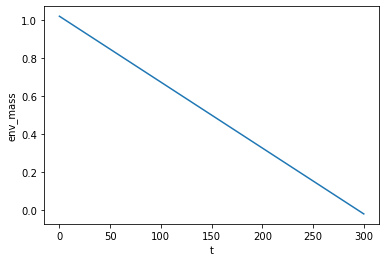

In [47]:
plt.figure()
last_episode_result.env_mass.plot.line(x="t")

In [20]:
a = pi * 0.5

env.sim.step((
    True,
    False,
    nb.int32(1),
    nb.float64(pi * 0.5),
))


TypeError: expected float64, got None

In [9]:
env.sim_states_dict()

{'t': '0.01',
 'action_engine_on': 'True',
 'action_drop_stage': 'False',
 'action_autopilot_mode': '1',
 'action_autopilot_reference': '1.5707963267948966',
 'ap_comm_gamma_e': '1.5707963267948966',
 'ap_comm_theta_e': '1.5707963267948966',
 'gii': '[-9.93822641e-17 -1.62303554e+00]',
 'xii': '[1.064463e-10 1.738400e+06]',
 'vii': '[1.04725536e-18 1.71029779e-02]',
 'aii': '[1.04732471e-16 1.71041106e+00]',
 'tei': '[[-1.000000e+00  6.123234e-17]\n [ 6.123234e-17  1.000000e+00]]',
 'vie': '[0.         0.01710298]',
 'fii_thrust': '[2.08189956e-16 3.40000000e+00]',
 'theta_i': '1.5707963267948966',
 'theta_i_dot': 'None',
 'theta_e': '1.5707963267948966',
 'mass': '1.0199653414882772',
 'mass_dot': '-0.0034658511722731908',
 'h': '1000.0',
 'engine_on': 'True',
 'stage_state': '1',
 'stage_idx': '0',
 'stage_ignitions_left': '-2',
 'gamma_i': '1.5707963267948966',
 'gamma_e': '1.5707963267948966',
 'longitude': '1.5707963267948966',
 'reward': '0',
 'score': '0.0',
 'done': 'True'}

In [ ]:
spec = [
    ("bar", nb.boolean),
    ("bas", nb.boolean),
    ("qux", nb.int32),
    ("qqq", nb.float64),
]
@jitclass(spec)
class Foo:
    def __init__(self):
        self.bar = 0
        self.bas = 0
        self.qux = 0
        self.qqq = 0
        
    def set(self, new_value):
        self.bar, self.bas, self.qux, self.qqq = new_value

In [ ]:
foo = Foo()

foo.set((
    True,
    False,
    nb.int32(1),
    nb.float64(pi * 0.5)
))